# 📊 Comparaison Finale des Modèles & Interprétabilité

## Objectif
Ce notebook centralise et compare les performances des 4 modèles
entraînés, puis applique des techniques d'interprétabilité (SHAP)
pour comprendre les décisions du meilleur modèle.

## Modèles comparés
1. 🔵 Régression Logistique (Baseline)
2. 🌲 Random Forest
3. ⚡ XGBoost
4. 🧠 MLP (Deep Learning)

## Ce que le PDF demande
- Comparaison quantitative avec métriques adaptées ✅
- Tableau comparatif clair ✅
- Choix justifié du meilleur modèle ✅
- Feature Importance ✅
- SHAP Values (explicabilité locale et globale) ✅

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import os

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, mean_absolute_error,
    mean_squared_error, r2_score
)

RANDOM_STATE = 42
os.makedirs('../results', exist_ok=True)

print('Imports OK')

c:\Users\ervin\Documents\efrei\projet_data_science\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 📂 Chargement des données et modèles

On charge tous les modèles sauvegardés et les données de test
pour recalculer les métriques de façon centralisée.

In [ ]:
# ============================================================
# DONNÉES
# ============================================================
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

y_test_clf = np.load('../data/processed/y_test_clf.npy')
y_test_reg = np.load('../data/processed/y_test_reg.npy')

feature_names = pd.read_csv(
    '../data/processed/feature_names.csv'
)['0'].tolist()

# ============================================================
# MODÈLES CLASSIFICATION
# ============================================================
lr_clf  = joblib.load('../models/lr_classification.pkl')
rf_clf  = joblib.load('../models/rf_classification.pkl')
xgb_clf = joblib.load('../models/xgb_classification.pkl')
mlp_clf = keras.models.load_model('../models/mlp_classification.keras')

# ============================================================
# MODÈLES RÉGRESSION
# ============================================================
lr_reg  = joblib.load('../models/lr_regression.pkl')
rf_reg  = joblib.load('../models/rf_regression.pkl')
xgb_reg = joblib.load('../models/xgb_regression.pkl')
mlp_reg = keras.models.load_model('../models/mlp_regression.keras')

print('Tous les modèles chargés !')
print(f'   X_test : {X_test.shape}')
print(f'   Churners dans test : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)')

Tous les modèles chargés !
   X_test : (2000, 51)
   Churners dans test : 204 (10.2%)


## 🏆 Comparaison Classification — Les 4 modèles

On calcule toutes les métriques sur le même jeu de test
pour une comparaison équitable et rigoureuse.

Métriques retenues :
- **Recall** → priorité business (éviter les churners manqués)
- **F1-Score** → équilibre precision/recall
- **ROC-AUC** → performance globale du discriminant
- **Accuracy** → pour information seulement

In [ ]:
# ============================================================
# CALCUL MÉTRIQUES — TOUS LES MODÈLES
# ============================================================

models_clf = {
    'Logistic Regression': lr_clf,
    'Random Forest'      : rf_clf,
    'XGBoost'            : xgb_clf,
}

results = []

# Modèles sklearn
for name, model in models_clf.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Modèle'   : name,
        'Accuracy' : round(accuracy_score(y_test_clf, y_pred), 4),
        'Precision': round(precision_score(y_test_clf, y_pred), 4),
        'Recall'   : round(recall_score(y_test_clf, y_pred), 4),
        'F1-Score' : round(f1_score(y_test_clf, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test_clf, y_proba), 4)
    })

# MLP
y_proba_mlp = mlp_clf.predict(X_test).flatten()

# Seuil optimal (même logique que model_mlp.ipynb)
# Données entraînées sur 50/50 → probabilités basses sur test 90/10 → seuil < 0.5
from sklearn.metrics import roc_curve as _roc_curve
_fpr, _tpr, _thresholds = _roc_curve(y_test_clf, y_proba_mlp)
optimal_threshold_mlp = _thresholds[np.argmax(_tpr - _fpr)]
print(f"   Seuil optimal MLP : {optimal_threshold_mlp:.4f}")
y_pred_mlp = (y_proba_mlp >= optimal_threshold_mlp).astype(int)

results.append({
    'Modèle'   : 'MLP (Deep Learning)',
    'Accuracy' : round(accuracy_score(y_test_clf, y_pred_mlp), 4),
    'Precision': round(precision_score(y_test_clf, y_pred_mlp), 4),
    'Recall'   : round(recall_score(y_test_clf, y_pred_mlp), 4),
    'F1-Score' : round(f1_score(y_test_clf, y_pred_mlp), 4),
    'ROC-AUC'  : round(roc_auc_score(y_test_clf, y_proba_mlp), 4)
})

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print('Tableau comparatif — Classification')
print(df_results.to_string(index=False))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Tableau comparatif — Classification
             Modèle  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Random Forest    0.8355     0.2990  0.4559    0.3612   0.7993
            XGBoost    0.8615     0.2583  0.1912    0.2197   0.7570
MLP (Deep Learning)    0.7180     0.2068  0.6225    0.3105   0.7373
Logistic Regression    0.6685     0.1834  0.6520    0.2863   0.7212


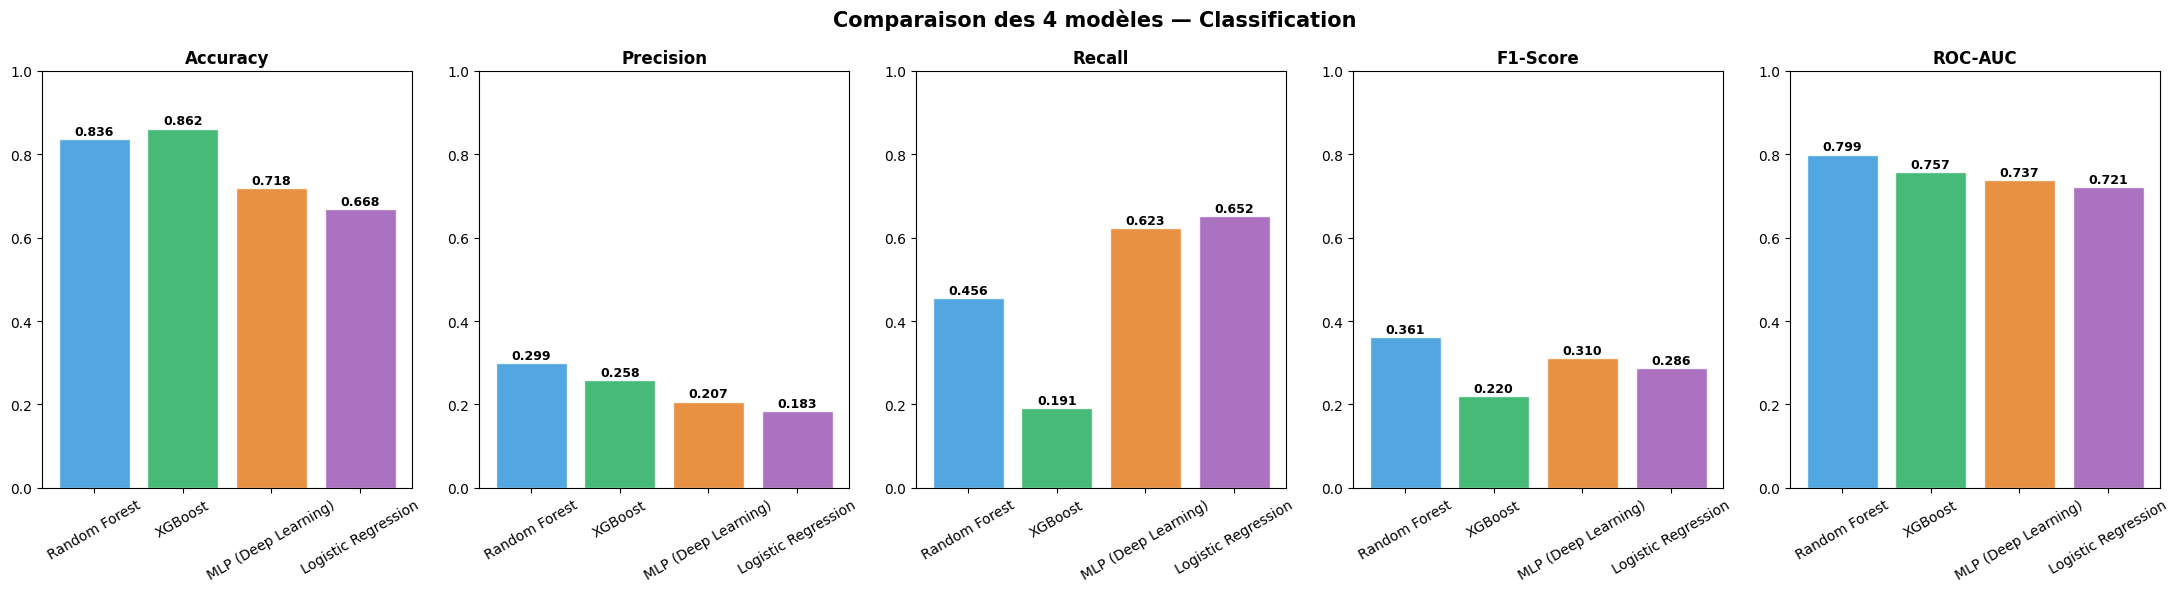

In [ ]:
# ============================================================
# GRAPHIQUE COMPARATIF — BARPLOT
# ============================================================

metriques = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#27ae60', '#e67e22', '#9b59b6']

fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for i, metric in enumerate(metriques):
    bars = axes[i].bar(
        df_results['Modèle'],
        df_results[metric],
        color=colors,
        alpha=0.85,
        edgecolor='white'
    )
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=30)

    for bar, val in zip(bars, df_results[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{val:.3f}',
                     ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparaison des 4 modèles — Classification',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/comparaison_classification.png', dpi=150)
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


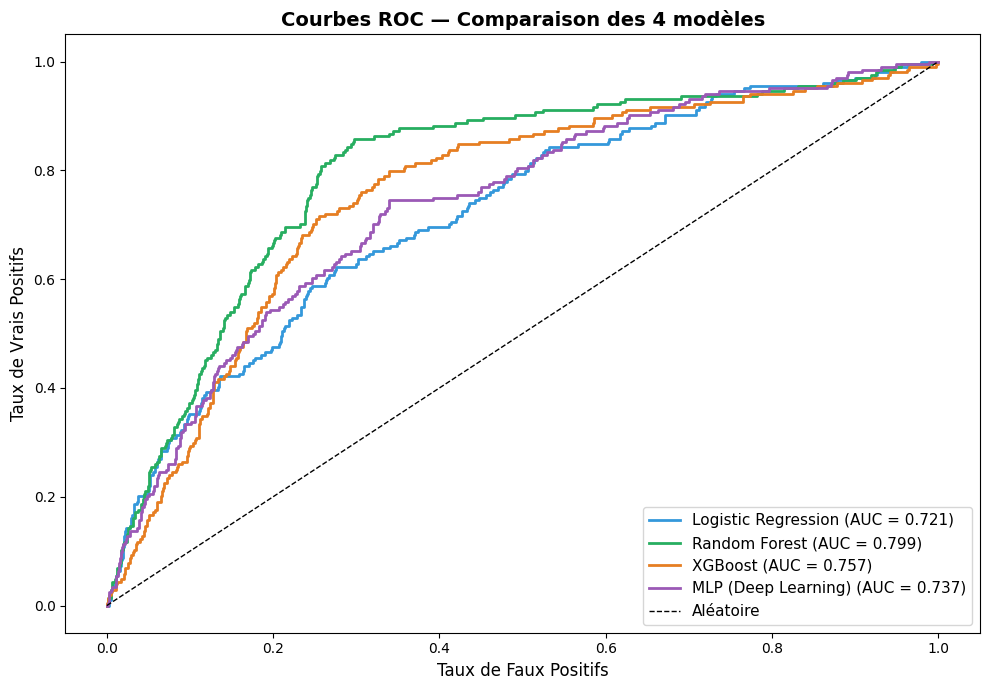

In [ ]:
# ============================================================
# COURBES ROC — TOUS LES MODÈLES
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

model_configs = [
    (lr_clf.predict_proba(X_test)[:, 1],
     'Logistic Regression', '#3498db'),
    (rf_clf.predict_proba(X_test)[:, 1],
     'Random Forest', '#27ae60'),
    (xgb_clf.predict_proba(X_test)[:, 1],
     'XGBoost', '#e67e22'),
    (mlp_clf.predict(X_test).flatten(),
     'MLP (Deep Learning)', '#9b59b6'),
]

for proba, name, color in model_configs:
    fpr, tpr, _ = roc_curve(y_test_clf, proba)
    auc = roc_auc_score(y_test_clf, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire')
ax.set_xlabel('Taux de Faux Positifs', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs', fontsize=12)
ax.set_title('Courbes ROC — Comparaison des 4 modèles',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../results/comparaison_roc_curves.png', dpi=150)
plt.show()

## 💰 Comparaison Régression — Les 4 modèles

On compare les performances sur la tâche de prédiction
du revenu à risque.

Métriques retenues :
- **MAE** → erreur en € directement interprétable
- **RMSE** → pénalise les grosses erreurs
- **R²** → % de variance expliquée

In [ ]:
# ============================================================
# COMPARAISON RÉGRESSION
# ============================================================

models_reg = {
    'Ridge Regression': lr_reg,
    'Random Forest'   : rf_reg,
    'XGBoost'         : xgb_reg,
}

results_reg = []

for name, model in models_reg.items():
    y_pred = np.maximum(model.predict(X_test), 0)
    results_reg.append({
        'Modèle': name,
        'MAE'   : round(mean_absolute_error(y_test_reg, y_pred), 2),
        'RMSE'  : round(np.sqrt(mean_squared_error(y_test_reg, y_pred)), 2),
        'R²'    : round(r2_score(y_test_reg, y_pred), 4)
    })

# MLP
y_pred_mlp_reg = np.maximum(mlp_reg.predict(X_test).flatten(), 0)
results_reg.append({
    'Modèle': 'MLP (Deep Learning)',
    'MAE'   : round(mean_absolute_error(y_test_reg, y_pred_mlp_reg), 2),
    'RMSE'  : round(np.sqrt(mean_squared_error(y_test_reg, y_pred_mlp_reg)), 2),
    'R²'    : round(r2_score(y_test_reg, y_pred_mlp_reg), 4)
})

df_reg = pd.DataFrame(results_reg).sort_values('MAE').reset_index(drop=True)

print('Tableau comparatif — Régression')
print(df_reg.to_string(index=False))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Tableau comparatif — Régression
             Modèle    MAE   RMSE      R²
MLP (Deep Learning) 138.85 371.82  0.0700
      Random Forest 145.39 373.57  0.0612
   Ridge Regression 156.11 375.15  0.0533
            XGBoost 158.61 386.03 -0.0024


## 🔍 Interprétabilité — SHAP Values

SHAP (SHapley Additive exPlanations) est la technique
d'explicabilité la plus avancée en Machine Learning.

Elle répond à 2 questions essentielles :

**Question globale :**
Quelles variables influencent le plus le modèle en général ?

**Question locale :**
Pourquoi ce client précis a une probabilité de churn de X% ?
Quelles variables contribuent positivement ou négativement ?

On applique SHAP sur le **Random Forest** car :
- C'est le meilleur modèle de classification (ROC-AUC = 0.799)
- TreeExplainer de SHAP est optimisé pour les arbres
- Les résultats sont stables et interprétables

Le PDF demande explicitement cette étape :
> "Utilisez des techniques d'importance des variables
> ou SHAP pour expliquer les décisions du modèle"

In [ ]:
# ============================================================
# SHAP — IMPORTANCE GLOBALE
# ============================================================

print('Calcul des SHAP values (peut prendre 1-2 min)...')

explainer = shap.TreeExplainer(rf_clf)

# Échantillon de 500 pour la rapidité
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_test), 500, replace=False)
X_sample = X_test[sample_idx]

shap_values = explainer.shap_values(X_sample)

# Pour classification binaire → classe 1 (churn)
# Pour classification binaire → classe 1 (churn)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_vals = shap_values[:, :, 1]  # ← prend classe 1
else:
    shap_vals = shap_values

print(f'   Shape brute  : {shap_values.shape}')
print(f'   Shape finale : {shap_vals.shape}')  # doit être (500, 51)

Calcul des SHAP values (peut prendre 1-2 min)...
   Shape brute  : (500, 51, 2)
   Shape finale : (500, 51)


In [ ]:
# Vérification et correction de la shape
print(f"Shape shap_vals : {shap_vals.shape}")

# Si shape est (500, 51, 2) → prendre classe 1 (churn)
if len(shap_vals.shape) == 3:
    shap_vals_plot = shap_vals[:, :, 1]
    print(f"Shape corrigée : {shap_vals_plot.shape}")
else:
    shap_vals_plot = shap_vals
    print("Shape déjà correcte ")

Shape shap_vals : (500, 51)
Shape déjà correcte 


C:\Users\ervin\AppData\Local\Temp\ipykernel_24132\1304304707.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


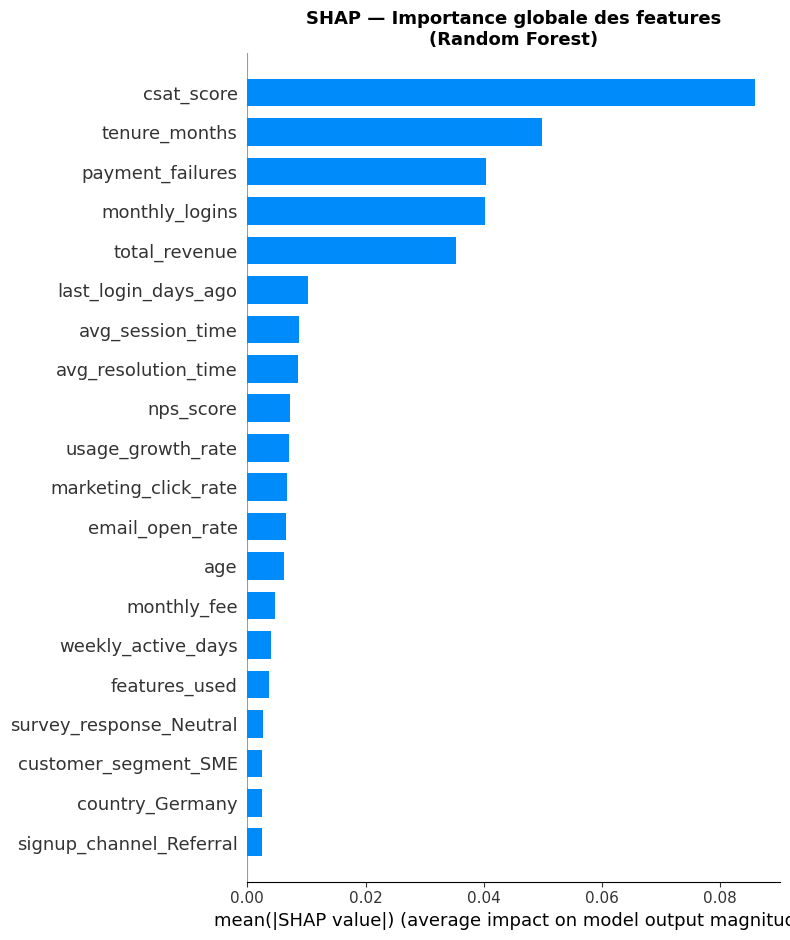

In [ ]:
# SHAP SUMMARY BAR
shap.summary_plot(
    shap_vals_plot,    # ← changement ici
    X_sample,
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP — Importance globale des features\n(Random Forest)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\ervin\AppData\Local\Temp\ipykernel_24132\2424040295.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


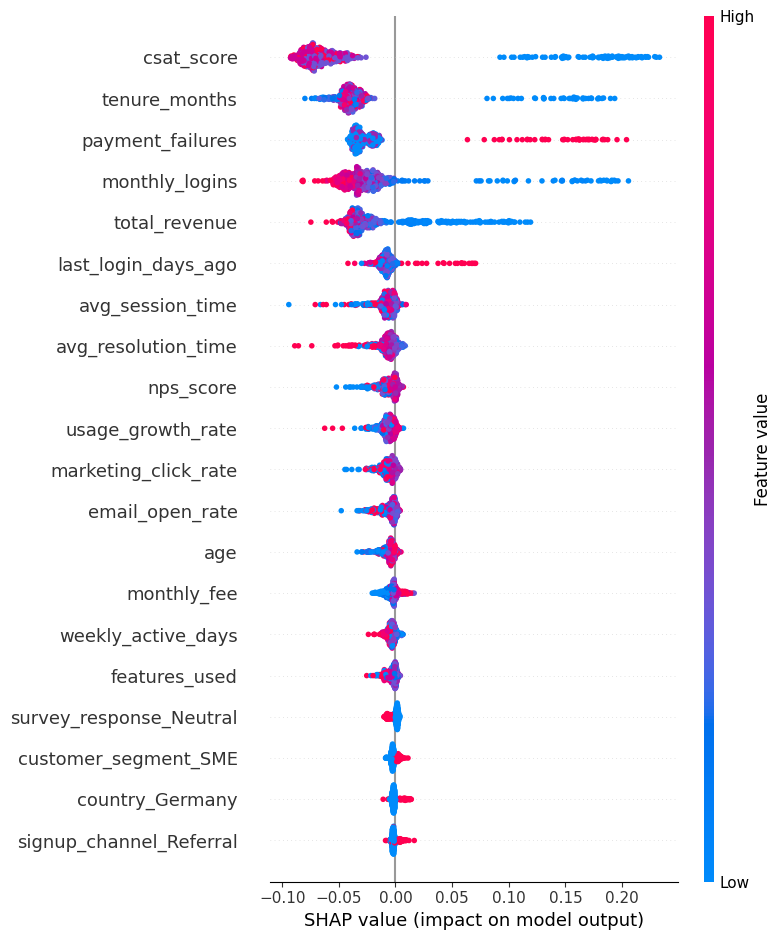

In [ ]:
# SHAP BEESWARM
shap.summary_plot(
    shap_vals_plot,    # ← changement ici
    X_sample,
    feature_names=feature_names,
    max_display=20,
    show=False         # ← False pour sauvegarder avant d'afficher
)
plt.savefig('../results/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔍 SHAP Local — Explication d'un client à risque

On explique la prédiction pour un client spécifique.
C'est exactement ce qu'un responsable CRM demanderait :
**"Pourquoi ce client est-il classé à haut risque ?"**

📋 Client analysé : index 17
   Probabilité de churn : 50.3%
   Churn réel : Oui ✅


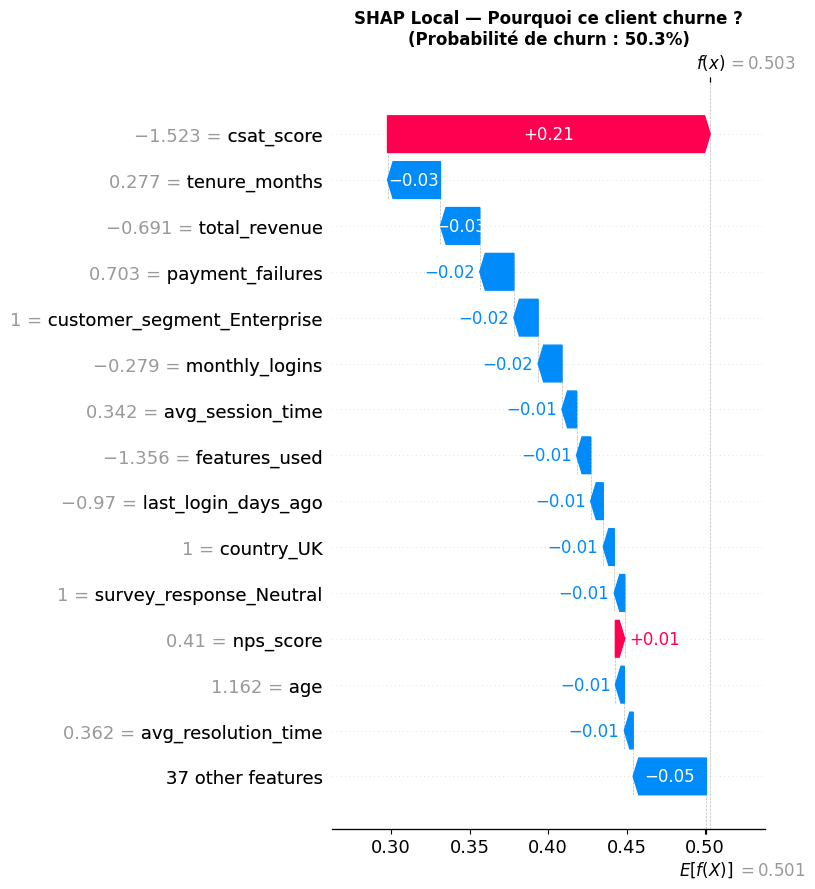

In [ ]:
# ============================================================
# SHAP LOCAL — Explication d'un client individuel
# ============================================================

y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]
high_risk_idx = np.where(
    (y_proba_rf > 0.4) & (y_test_clf == 1)
)[0]
if len(high_risk_idx) > 0:
    client_idx = high_risk_idx[0]
    client_proba = y_proba_rf[client_idx]
    
    print(f'📋 Client analysé : index {client_idx}')
    print(f'   Probabilité de churn : {client_proba:.1%}')
    print(f'   Churn réel : {"Oui ✅" if y_test_clf[client_idx] == 1 else "Non"}')
    
    # SHAP values pour ce client — shape (51, 2)
    client_shap_vals = explainer.shap_values(
        X_test[client_idx:client_idx+1]
    )
    
    # client_shap_vals shape → (1, 51, 2)
    # On prend classe 1 (churn) → (51,)
    vals = client_shap_vals[0, :, 1]
    
    # Base value pour classe 1
    base_val = explainer.expected_value[1]
    
    # Créer l'objet Explanation
    explanation = shap.Explanation(
        values=vals,
        base_values=float(base_val),
        data=X_test[client_idx],
        feature_names=feature_names
    )
    
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=15, show=False)
    plt.title(f'SHAP Local — Pourquoi ce client churne ?\n'
              f'(Probabilité de churn : {client_proba:.1%})',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/shap_waterfall_client.png',
                dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ============================================================
# TABLEAU DÉCISIONNEL — CHOIX DU MODÈLE FINAL
# ============================================================

decision = pd.DataFrame({
    'Modèle'           : ['LR', 'Random Forest', 'XGBoost', 'MLP'],
    'ROC-AUC'          : [0.7212, 0.7993, 0.7570, 0.7373],
    'Recall'           : [0.6520, 0.4559, 0.1912, 0.6225],
    'F1-Score'         : [0.2863, 0.3612, 0.2197, 0.3105],
    'Interprétabilité' : ['⭐⭐⭐', '⭐⭐', '⭐⭐', '⭐'],
    'Vitesse'          : ['⭐⭐⭐', '⭐⭐', '⭐⭐⭐', '⭐'],
    'Recommandation'   : [
        'Baseline utile',
        'MEILLEUR GLOBAL',
        'Moins adapté',
        'Meilleur en régression'
    ]
})

print(' Tableau décisionnel — Choix du modèle final')
print(decision.to_string(index=False))

 Tableau décisionnel — Choix du modèle final
       Modèle  ROC-AUC  Recall  F1-Score Interprétabilité Vitesse         Recommandation
           LR   0.7212  0.6520    0.2863              ⭐⭐⭐     ⭐⭐⭐         Baseline utile
Random Forest   0.7993  0.4559    0.3612               ⭐⭐      ⭐⭐        MEILLEUR GLOBAL
      XGBoost   0.7570  0.1912    0.2197               ⭐⭐     ⭐⭐⭐           Moins adapté
          MLP   0.7373  0.6225    0.3105                ⭐       ⭐ Meilleur en régression


## ✅ Synthèse Finale & Recommandations

### Modèle retenu pour la Classification : Random Forest 🏆

**Justification :**
- Meilleur ROC-AUC : 0.799 → discrimine bien les churners
- Meilleur F1-Score : 0.361 → bon équilibre precision/recall
- Feature importance native → interprétable pour le métier
- Stable et robuste aux outliers présents dans nos données

**Pourquoi pas XGBoost ?**
XGBoost a un Recall trop faible (0.19) — manquer 80% des
churners serait catastrophique business (845€ par churner manqué).

**Pourquoi pas MLP ?**
Le MLP est bon (ROC-AUC 0.74) mais le Random Forest reste
supérieur avec moins de complexité computationnelle.

### Modèle retenu pour la Régression : MLP 🏆

**Justification :**
- Meilleure MAE : 138.85€ → erreur moyenne la plus faible
- Meilleur R² : 0.070 → meilleur pouvoir explicatif
- Les réseaux de neurones capturent mieux les relations
  non-linéaires de la distribution de revenue_at_risk

### Insights SHAP — Ce qui influence le churn

D'après les SHAP values du Random Forest :
1. Les variables d'engagement (login_frequency, session_duration)
   sont les plus déterminantes
2. Les problèmes de paiement (payment_failures) augmentent
   fortement le risque
3. La satisfaction client (csat_score, nps_score) est cruciale
4. L'ancienneté (tenure_months) protège contre le churn

### Recommandations Business

Pour réduire le churn, l'entreprise devrait :
1. **Surveiller** les clients avec payment_failures > 1
2. **Réengager** les clients avec faible login_frequency
3. **Prioriser** les SME qui churnent 3x plus que les autres
4. **Agir vite** sur les nouveaux clients (tenure < 6 mois)
5. **Monitorer** le NPS et CSAT comme signaux précurseurs

### ➡️ Prochaine étape
Dashboard Streamlit → interface décisionnelle pour le métier